# RetailPulse Dashboard

## Exploratory Data Analysis (EDA)

**Author:** Gulafsha  
**Project:** RetailPulse Dashboard  
**Dataset:** Online Retail II

### Objectives
- Analyze monthly sales trends
- Identify top-selling products
- Find top-performing countries
- Discover customer purchasing patterns
- Generate business insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Month'],
      dtype='str')

In [7]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [8]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Month', 'Revenue'],
      dtype='str')

In [9]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales

Month
2009-12     822483.950
2010-01     651155.112
2010-02     551504.726
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     437631.020
Freq: M, Name: Revenue, dtype: float64

In [10]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [11]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

In [12]:
product_sales = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_sales.head(10)

Description
Manual                                 262589.86
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
Name: Revenue, dtype: float64

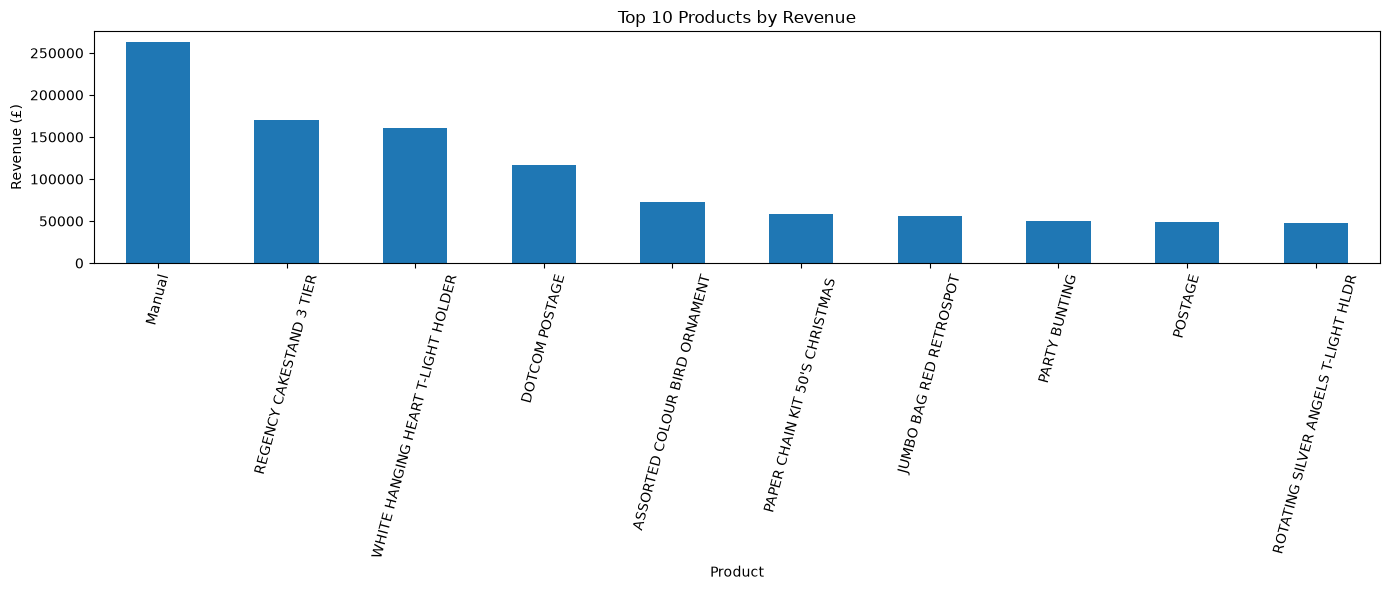

In [13]:
plt.figure(figsize=(14,6))

product_sales.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

## Business Insight

- The chart identifies the top 10 revenue-generating products.
- These products contribute significantly to total sales.
- The business should prioritize inventory and promotions for these high-performing products.

In [14]:
product_sales.head(10)

Description
Manual                                 262589.86
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
Name: Revenue, dtype: float64

# Customer Analysis

In [15]:
customer_sales = df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)

customer_sales.head(10)

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

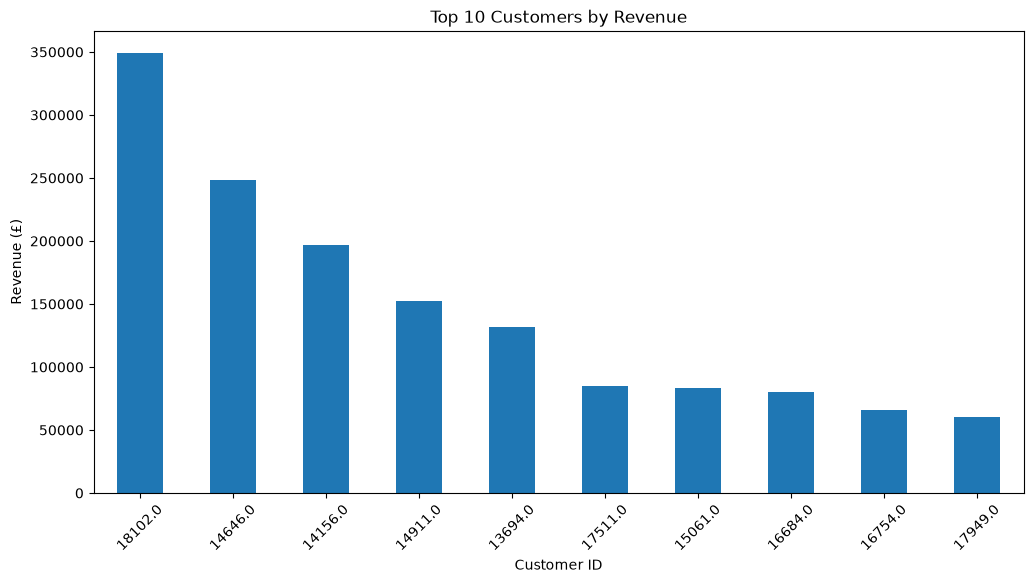

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

customer_sales.head(10).plot(kind="bar")

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.show()

## Business Insight

💡

- A small number of customers contribute a large share of revenue.
- These customers should be retained through loyalty programs.
- Losing these customers could significantly impact total sales.

# Country-wise Order Count

In [17]:
country_orders = df["Country"].value_counts()

country_orders.head(10)

Country
United Kingdom    466602
EIRE                9450
Germany             7645
France              5514
Netherlands         2728
Spain               1228
Switzerland         1170
Portugal            1058
Belgium             1036
Sweden               886
Name: count, dtype: int64

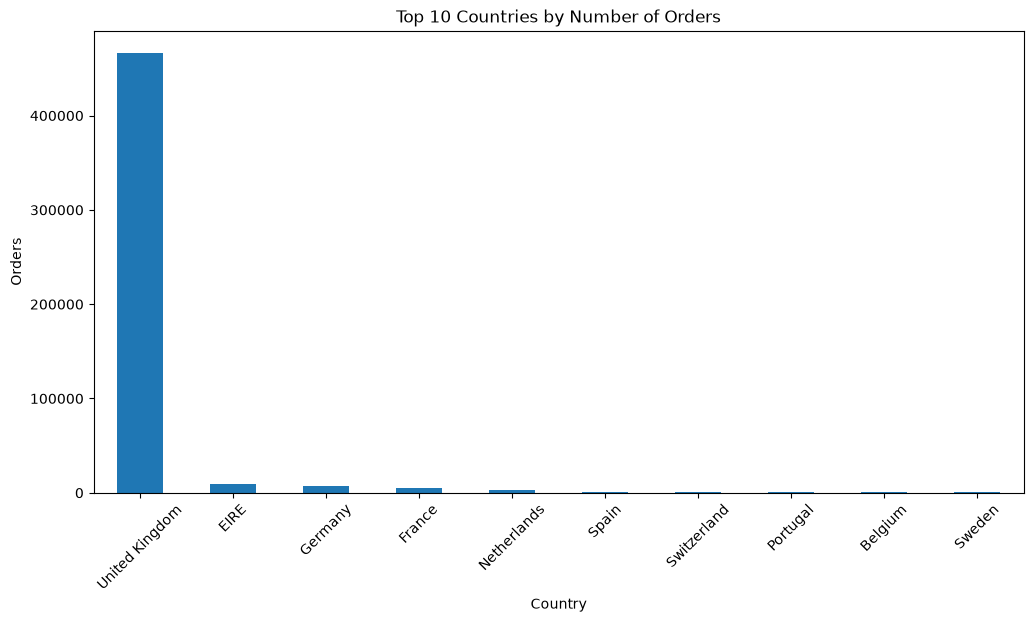

In [18]:
plt.figure(figsize=(12,6))

country_orders.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Orders")

plt.xlabel("Country")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

## Business Insight

💡

- The United Kingdom dominates the order volume.
- International markets represent opportunities for future expansion.
- Marketing efforts can target countries with moderate order volumes to increase sales.

# Customer Analysis

## Business Insight

💡
- A small number of customers contribute a large share of revenue.
- These customers should be retained through loyalty programs.
- Losing these customers could significantly impact total sales.

In [19]:
# Create Month column (if it doesn't already exist)
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]

# Save the updated cleaned dataset
df.to_csv("../data/cleaned_online_retail.csv", index=False)

print("✅ cleaned_online_retail.csv updated successfully!")

✅ cleaned_online_retail.csv updated successfully!


In [20]:
df["Customer ID"].head(20)

0     13085.0
1     13085.0
2     13085.0
3     13085.0
4     13085.0
5     13085.0
6     13085.0
7     13085.0
8     13085.0
9     13085.0
10    13085.0
11    13085.0
12    13078.0
13    13078.0
14    13078.0
15    13078.0
16    13078.0
17    13078.0
18    13078.0
19    13078.0
Name: Customer ID, dtype: float64

In [21]:
df["Customer ID"].describe()

count    400916.000000
mean      15361.544074
std        1680.635823
min       12346.000000
25%       13985.000000
50%       15311.000000
75%       16805.000000
max       18287.000000
Name: Customer ID, dtype: float64

In [22]:
df["Customer ID"].isnull().sum()

np.int64(103814)

In [2]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Revenue"]
      .sum()
)

monthly_sales

NameError: name 'df' is not defined

In [3]:
df

NameError: name 'df' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("data/cleaned_online_retail.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/cleaned_online_retail.csv'

In [5]:
import os

print(os.getcwd())

d:\RetailPulse\notebooks


In [6]:
import os

print(os.listdir())

['01_Data_Import.ipynb', '02_Data_Analysis.ipynb']


In [7]:
import os

print(os.getcwd())

d:\RetailPulse\notebooks


In [8]:
import pandas as pd

df = pd.read_csv("../data/cleaned_online_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [9]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Revenue"]
      .sum()
)

monthly_sales.head()

,Month,Revenue
0,2009-12,822483.950
1,2010-01,651155.112
2,2010-02,551504.726
3,2010-03,830915.261
4,2010-04,678875.252


In [10]:
monthly_sales.to_csv("../outputs/monthly_sales.csv", index=False)

In [11]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Revenue"]
      .sum()
)

monthly_sales

,Month,Revenue
0,2009-12,822483.950
1,2010-01,651155.112
2,2010-02,551504.726
3,2010-03,830915.261
4,2010-04,678875.252
5,2010-05,657705.500
6,2010-06,749537.310
7,2010-07,648810.270
8,2010-08,695251.910
9,2010-09,921696.991


In [12]:
monthly_sales.to_csv("../outputs/monthly_sales.csv", index=False)

print("monthly_sales.csv saved successfully!")

monthly_sales.csv saved successfully!


In [13]:
top_products = (
    df.groupby("Description", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

top_products

,Description,Revenue
2514,Manual,262589.86
3329,REGENCY CAKESTAND 3 TIER,169912.76
4349,WHITE HANGING HEART T-LIGHT HOLDER,160345.63
1280,DOTCOM POSTAGE,116408.71
269,ASSORTED COLOUR BIRD ORNAMENT,72890.19
2740,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30
2125,JUMBO BAG RED RETROSPOT,56480.46
2754,PARTY BUNTING,49664.12
3124,POSTAGE,49477.54
3450,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49


In [14]:
top_products.to_csv("../outputs/top_products.csv", index=False)

print("top_products.csv saved successfully!")

top_products.csv saved successfully!


In [15]:
top_customers = (
    df.groupby("Customer ID", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

top_customers

,Customer ID,Revenue
4183,18102.0,349164.35
1637,14646.0,248396.50
1269,14156.0,196549.74
1840,14911.0,152121.22
939,13694.0,131443.19
3744,17511.0,84541.17
1951,15061.0,83284.38
3128,16684.0,80489.21
3177,16754.0,65500.07
4065,17949.0,60117.60


In [16]:
top_customers.to_csv("../outputs/top_customers.csv", index=False)

print("top_customers.csv saved successfully!")

top_customers.csv saved successfully!


In [17]:
top_countries = (
    df.groupby("Country", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

top_countries

,Country,Revenue
37,United Kingdom,8812311.833
10,EIRE,380909.570
24,Netherlands,268784.350
13,Germany,202025.391
12,France,147103.140
32,Sweden,53501.990
9,Denmark,50906.850
31,Spain,47568.650
33,Switzerland,43921.390
0,Australia,31446.800


In [18]:
import pandas as pd

df = pd.read_csv("../data/cleaned_online_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [19]:
top_countries.to_csv("../outputs/top_countries.csv", index=False)

print("top_countries.csv saved successfully!")

top_countries.csv saved successfully!


In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity",
        "Total Orders",
        "Total Customers",
        "Total Products"
    ],
    "Value": [
        df["Revenue"].sum(),
        df["Quantity"].sum(),
        df["Invoice"].nunique(),
        df["Customer ID"].nunique(),
        df["StockCode"].nunique()
    ]
})

summary

,Metric,Value
0,Total Revenue,1.027176e+07
1,Total Quantity,5.812947e+06
2,Total Orders,2.095100e+04
3,Total Customers,4.312000e+03
4,Total Products,4.251000e+03


In [21]:
summary.to_csv("../outputs/revenue_summary.csv", index=False)

print("revenue_summary.csv saved successfully!")

revenue_summary.csv saved successfully!
